# Test Notebook: Importing OpenFOAM Case - Multi Region
This notebook checks the functionalities of the pyforce package to handle OpenFOAM cases with multiple regions. It verifies that the package can correctly read and process the case files, adopting either *pyvista* or *fluidfoam* or *foamlib* as the backend.

In [1]:
from pyforce.tools.write_read import ReadFromOFMultiRegion
import time

path_case = 'TestDatasets/reverseBurner/'

of_reconstructed = ReadFromOFMultiRegion(path_case, skip_zero_time=True, decomposed_case=False)
of_decomposed    = ReadFromOFMultiRegion(path_case, skip_zero_time=True, decomposed_case=True)

regions = of_reconstructed.regions

Case Type decomposed


Let us plot the mesh

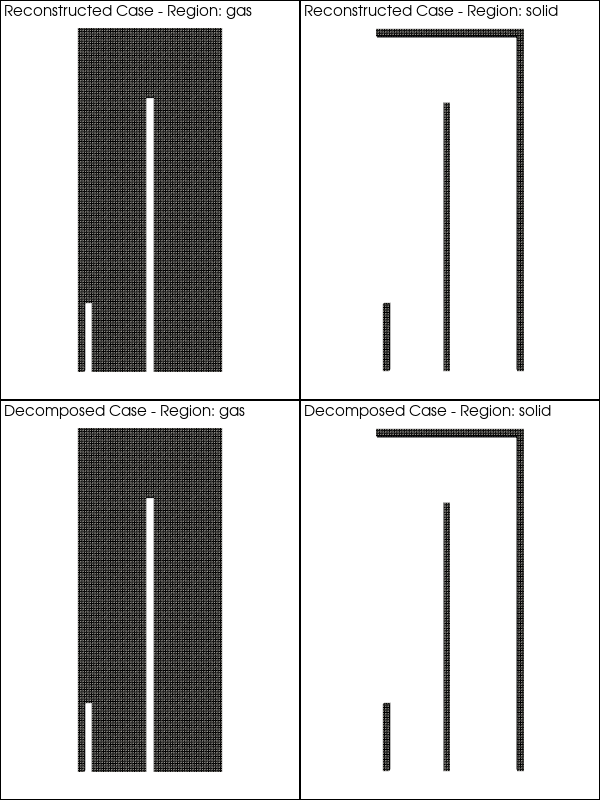

In [2]:
grids = {
    'reconstructed': [of_reconstructed._region_mesh(region) for region in regions],
    'decomposed': [of_decomposed._region_mesh(region) for region in regions]
}

import pyvista as pv
pl = pv.Plotter(shape=(2, len(regions)), window_size=(300 * len(regions), 400 * 2))

for ii, region in enumerate(regions):
    pl.subplot(0, ii)
    pl.add_text('Reconstructed Case - Region: ' + region, font_size=12)
    pl.add_mesh(grids['reconstructed'][ii], show_edges=True, color='white')
    pl.view_xy()
    pl.camera.zoom(1.25)

    pl.subplot(1, ii)
    pl.add_text('Decomposed Case - Region: ' + region, font_size=12)
    pl.add_mesh(grids['decomposed'][ii], show_edges=True, color='white')
    pl.view_xy()
    pl.camera.zoom(1.25)
    

pl.show(jupyter_backend='static')

## Reconstructed Case
The first check is on reconstructed data (either with \texttt{reconstructPar} or solved with single processor). Let us import the snapshots for the velocity and turbulent viscosity fields.

In [3]:
fields = ['p', 'T', 'U']

comput_times_reconstructed  = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

snapshots_reconstructed = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}


for field in fields:

    # Pyvista backend
    start_process_time = time.process_time()
    snapshots_reconstructed['Pyvista'][field] = of_reconstructed.import_field(field, import_mode='pyvista')
    comput_times_reconstructed['Pyvista'][field] = time.process_time() - start_process_time

    # FluidFoam backend
    start_process_time = time.process_time()
    snapshots_reconstructed['FluidFoam'][field] = of_reconstructed.import_field(field, import_mode='fluidfoam')
    comput_times_reconstructed['FluidFoam'][field] = time.process_time() - start_process_time

    # FoamLib backend
    start_process_time = time.process_time()
    snapshots_reconstructed['FoamLib'][field] = of_reconstructed.import_field(field, import_mode='foamlib')
    comput_times_reconstructed['FoamLib'][field] = time.process_time() - start_process_time

Ns = len(snapshots_reconstructed['Pyvista'][fields[0]])

Importing p from all regions - pyvista: 2.000 / 2.00 - 0.168110 s/it
Importing p from all regions - fluidfoam: 2.000 / 2.00 - 0.031586 s/it
Importing p from all regions - foamlib: 2.000 / 2.00 - 0.022660 s/it
Importing T from all regions - pyvista: 2.000 / 2.00 - 0.137461 s/it
Importing T from all regions - fluidfoam: 2.000 / 2.00 - 0.032072 s/it
Importing T from all regions - foamlib: 2.000 / 2.00 - 0.021769 s/it
Importing U from all regions - pyvista: 1.000 / 1.00 - 0.000062 s/it
Importing U from all regions - fluidfoam: 1.000 / 1.00 - 0.000081 s/it
Importing U from all regions - foamlib: 1.000 / 1.00 - 0.000018 s/it


Plot a comparison of the computational times for both backends. 

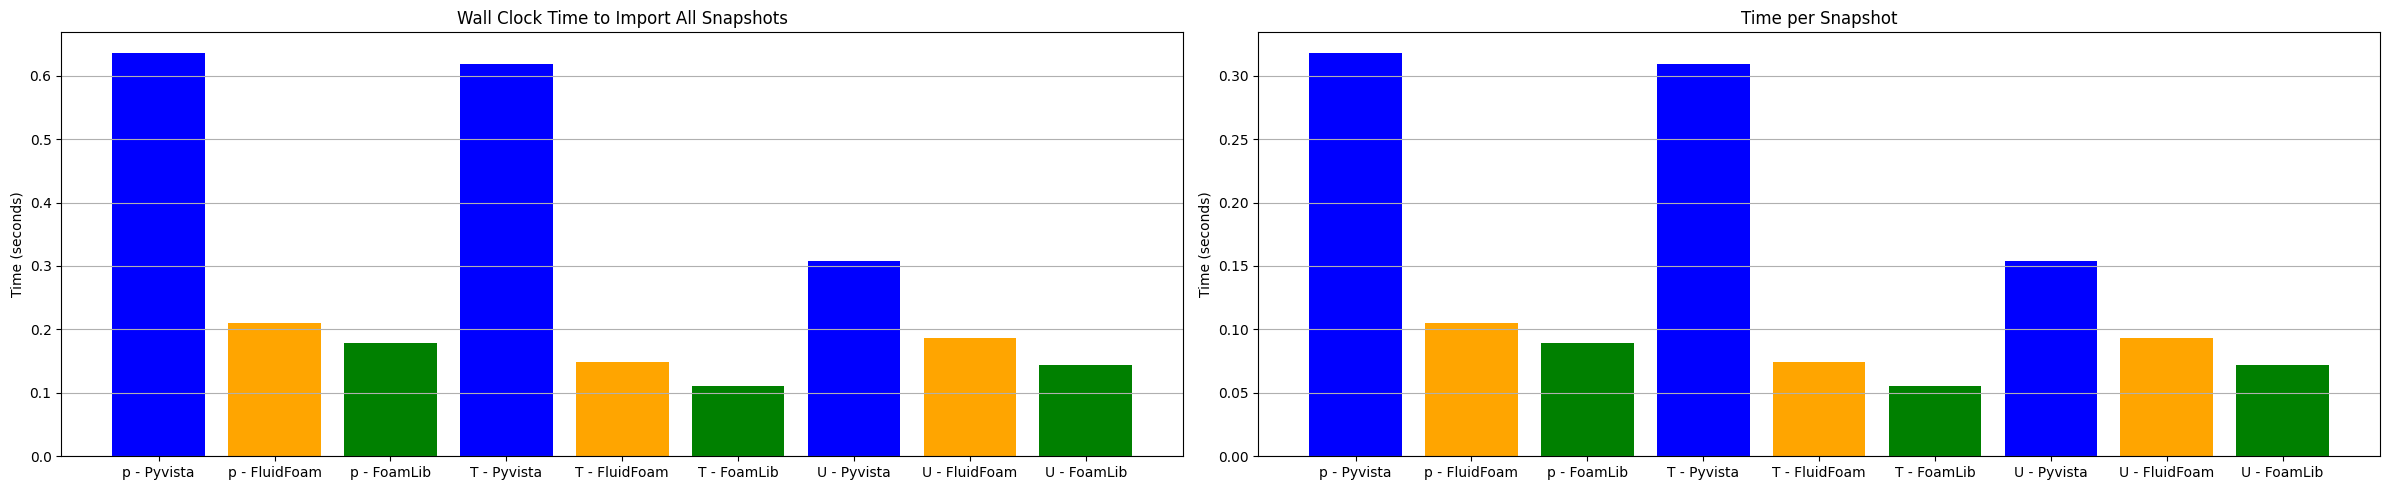

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(8 * len(fields), 5))
axs = axs.flatten()

for field in fields:
    axs[0].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_reconstructed['Pyvista'][field], comput_times_reconstructed['FluidFoam'][field], comput_times_reconstructed['FoamLib'][field]], color=['blue', 'orange', 'green'])

    axs[1].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_reconstructed['Pyvista'][field] / Ns, comput_times_reconstructed['FluidFoam'][field] / Ns, comput_times_reconstructed['FoamLib'][field] / Ns], color=['blue', 'orange', 'green'])

axs[0].set_title('Wall Clock Time to Import All Snapshots')
axs[1].set_title('Time per Snapshot')

for ax in axs:
    ax.set_ylabel('Time (seconds)')
    ax.grid(True, axis='y')

plt.tight_layout()

Plot for checking the fields

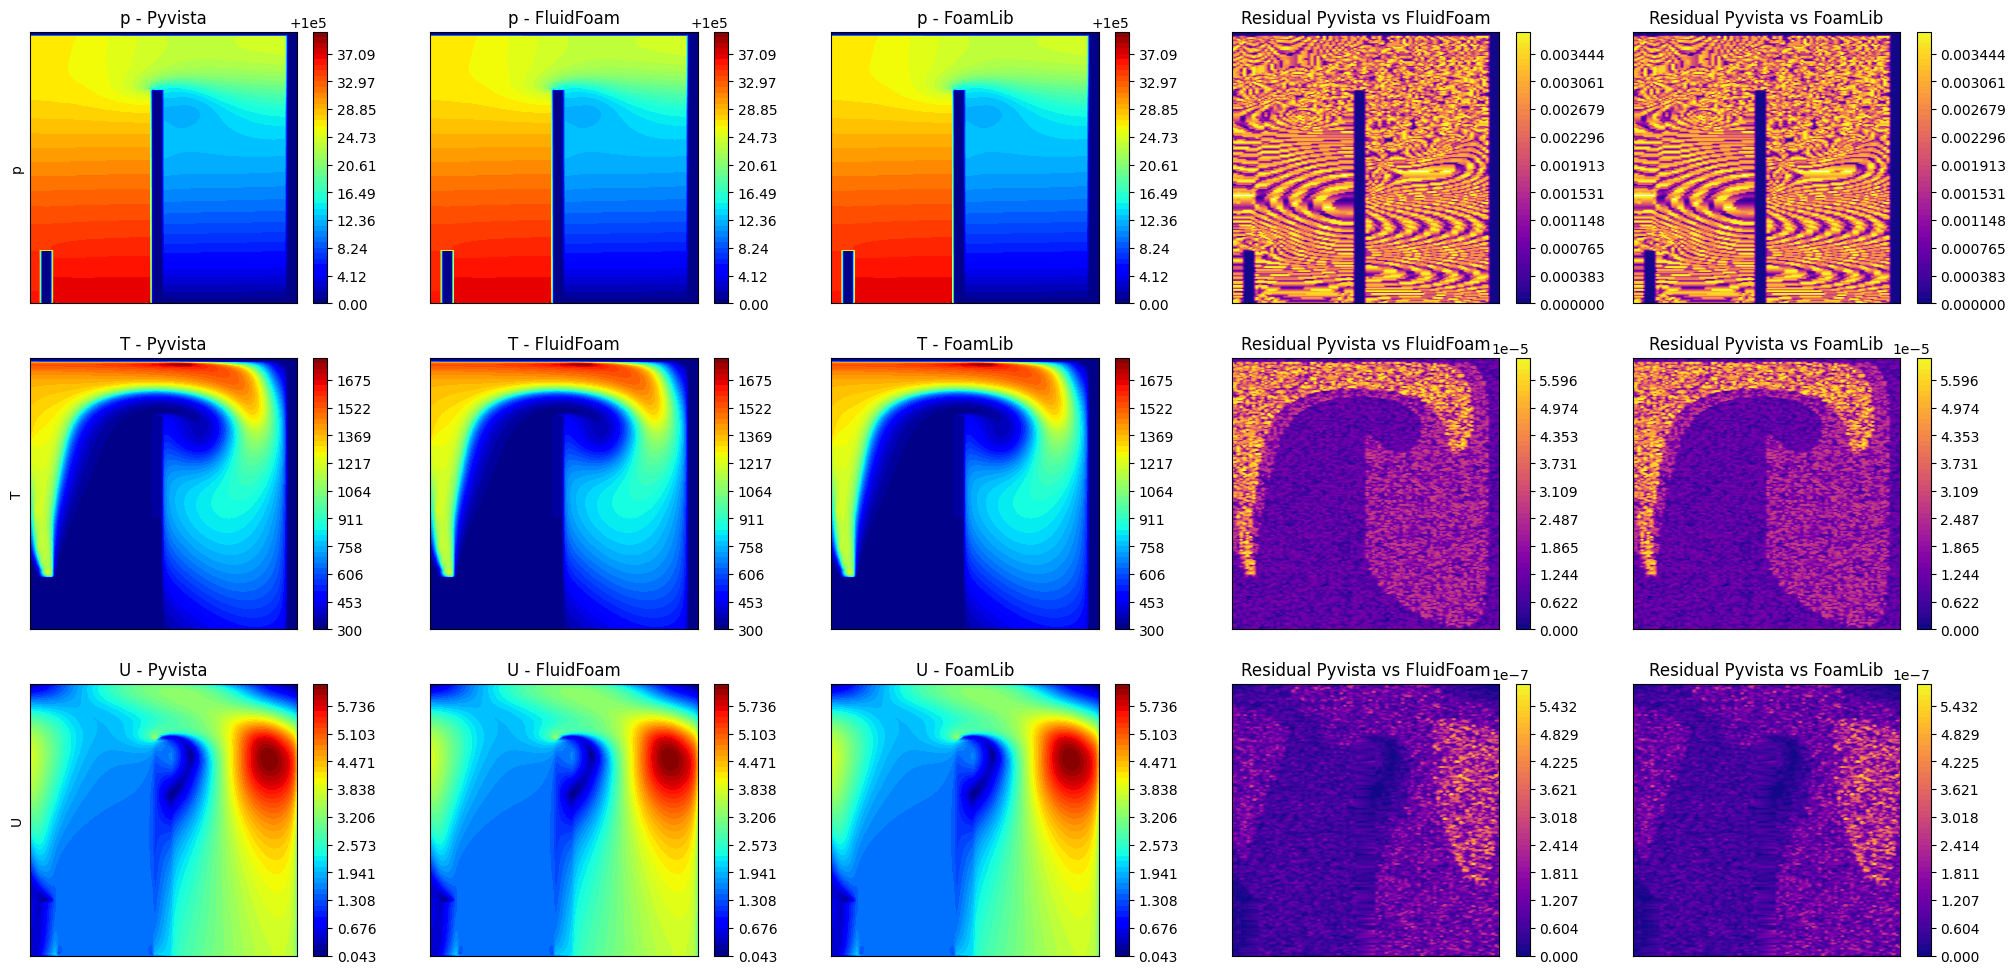

In [5]:
import numpy as np
nodes_full_mesh = of_reconstructed.mesh().cell_centers().points
nodes_gas_mesh  = of_reconstructed._region_mesh('gas').cell_centers().points

fig, axs = plt.subplots(len(fields), (len(snapshots_reconstructed.keys())*2-1), figsize=(5 * (len(snapshots_reconstructed.keys())*2-1), 4 * len(fields)))

for i, field in enumerate(fields):
    pv_res_reconstructed = snapshots_reconstructed['Pyvista'][field][0](-1)
    ff_res_reconstructed = snapshots_reconstructed['FluidFoam'][field][0](-1)
    fl_res_reconstructed = snapshots_reconstructed['FoamLib'][field][0](-1)

    if field == 'U':
        _ff = np.linalg.norm(ff_res_reconstructed.reshape(-1, 3), axis=1)
        _pv = np.linalg.norm(pv_res_reconstructed.reshape(-1, 3), axis=1)
        _fl = np.linalg.norm(fl_res_reconstructed.reshape(-1, 3), axis=1)
        _mesh = nodes_gas_mesh
    else:
        _ff = ff_res_reconstructed
        _pv = pv_res_reconstructed
        _fl = fl_res_reconstructed
        _mesh = nodes_full_mesh

    levels = np.linspace(min(_ff.min(), _pv.min(), _fl.min()), max(_ff.max(), _pv.max(), _fl.max()), 50)

    c = axs[i, 0].tricontourf(_mesh[:, 0], _mesh[:, 1], _pv, levels=levels, cmap='jet')
    axs[i, 1].tricontourf(_mesh[:, 0], _mesh[:, 1], _ff, levels=levels, cmap='jet')
    axs[i, 2].tricontourf(_mesh[:, 0], _mesh[:, 1], _fl, levels=levels, cmap='jet')

    _res_ff = np.abs(_ff - _pv)
    _res_fl = np.abs(_fl - _pv)
    res_levels = np.linspace(0, max(_res_ff.max(), _res_fl.max()), 50)
    
    c_res = axs[i, 3].tricontourf(_mesh[:, 0], _mesh[:, 1], _res_ff, levels=res_levels, cmap='plasma')
    axs[i, 4].tricontourf(_mesh[:, 0], _mesh[:, 1], _res_fl, levels=res_levels, cmap='plasma')

    fig.colorbar(c, ax=axs[i, 0])
    fig.colorbar(c, ax=axs[i, 1])
    fig.colorbar(c, ax=axs[i, 2])

    fig.colorbar(c_res, ax=axs[i, 3])
    fig.colorbar(c_res, ax=axs[i, 4])

    axs[i, 0].set_title(f'{field} - Pyvista')
    axs[i, 1].set_title(f'{field} - FluidFoam')
    axs[i, 2].set_title(f'{field} - FoamLib')

    axs[i, 3].set_title(f'Residual Pyvista vs FluidFoam')
    axs[i, 4].set_title(f'Residual Pyvista vs FoamLib')

    axs[i, 0].set_ylabel(f'{field}')

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

## Decomposed Case

The second check is on decomposed data. 

In [6]:
comput_times_decomposed  = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

snapshots_decomposed = {
    'Pyvista': {},
    'FluidFoam': {},
    'FoamLib': {}
}

for field in fields:

    # Pyvista backend
    start_process_time = time.process_time()
    snapshots_decomposed['Pyvista'][field] = of_decomposed.import_field(field, import_mode='pyvista')
    comput_times_decomposed['Pyvista'][field] = time.process_time() - start_process_time

    # FluidFoam backend
    start_process_time = time.process_time()
    snapshots_decomposed['FluidFoam'][field] = of_decomposed.import_field(field, import_mode='fluidfoam')
    comput_times_decomposed['FluidFoam'][field] = time.process_time() - start_process_time

    # FoamLib backend
    start_process_time = time.process_time()
    snapshots_decomposed['FoamLib'][field] = of_decomposed.import_field(field, import_mode='foamlib')
    comput_times_decomposed['FoamLib'][field] = time.process_time() - start_process_time

Importing p from all regions - pyvista: 2.000 / 2.00 - 0.271272 s/it
Importing p from all regions - fluidfoam: 2.000 / 2.00 - 0.032522 s/it
Importing p from all regions - foamlib: 2.000 / 2.00 - 0.039358 s/it
Importing T from all regions - pyvista: 2.000 / 2.00 - 0.170214 s/it
Importing T from all regions - fluidfoam: 2.000 / 2.00 - 0.035121 s/it
Importing T from all regions - foamlib: 2.000 / 2.00 - 0.046138 s/it
Importing U from all regions - pyvista: 1.000 / 1.00 - 0.000016 s/it
Importing U from all regions - fluidfoam: 1.000 / 1.00 - 0.000082 s/it
Importing U from all regions - foamlib: 1.000 / 1.00 - 0.000017 s/it


Plot a comparison of the computational times for both backends. 

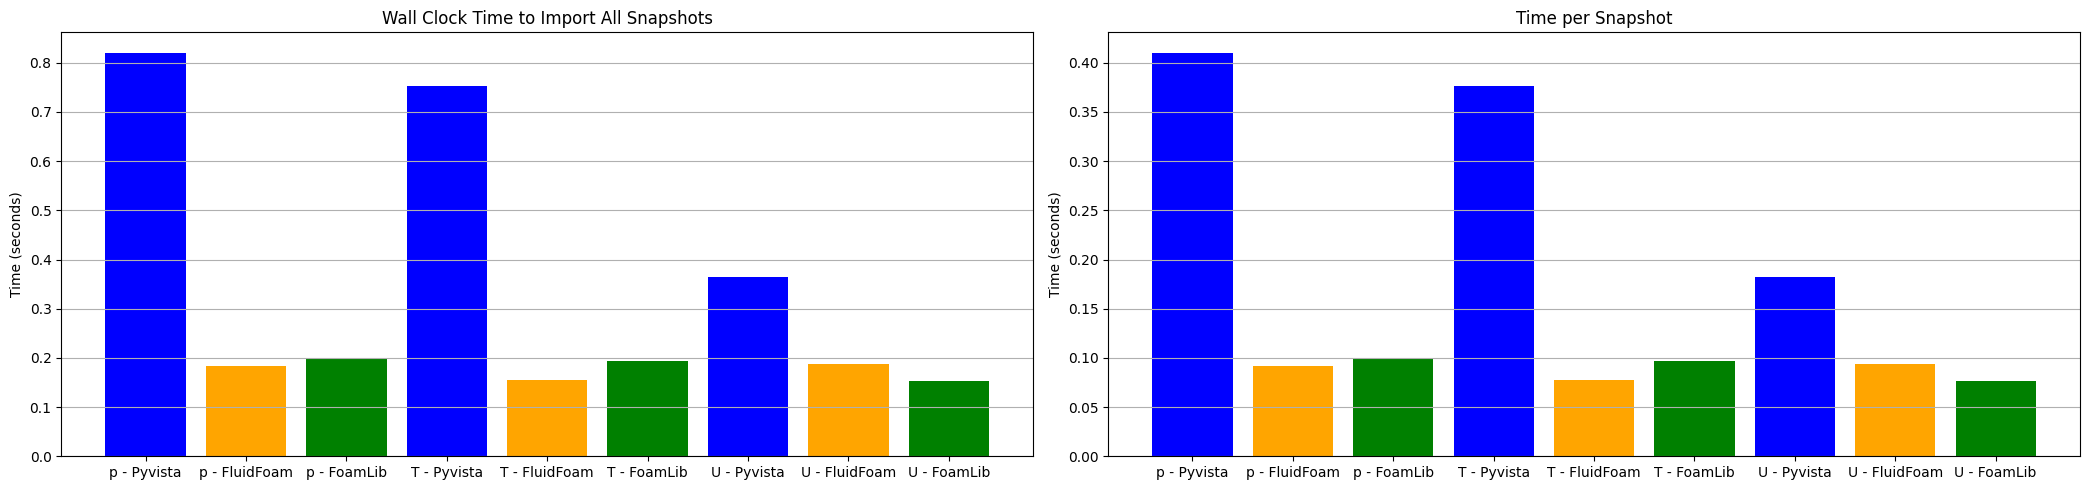

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(7 * len(fields), 5))
axs = axs.flatten()

for field in fields:
    axs[0].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_decomposed['Pyvista'][field], comput_times_decomposed['FluidFoam'][field], comput_times_decomposed['FoamLib'][field]], color=['blue', 'orange', 'green'])

    axs[1].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_decomposed['Pyvista'][field] / Ns, comput_times_decomposed['FluidFoam'][field] / Ns, comput_times_decomposed['FoamLib'][field] / Ns], color=['blue', 'orange', 'green'])    

axs[0].set_title('Wall Clock Time to Import All Snapshots')
axs[1].set_title('Time per Snapshot')

for ax in axs:
    ax.set_ylabel('Time (seconds)')
    ax.grid(True, axis='y')

plt.tight_layout()

Plot for checking the fields

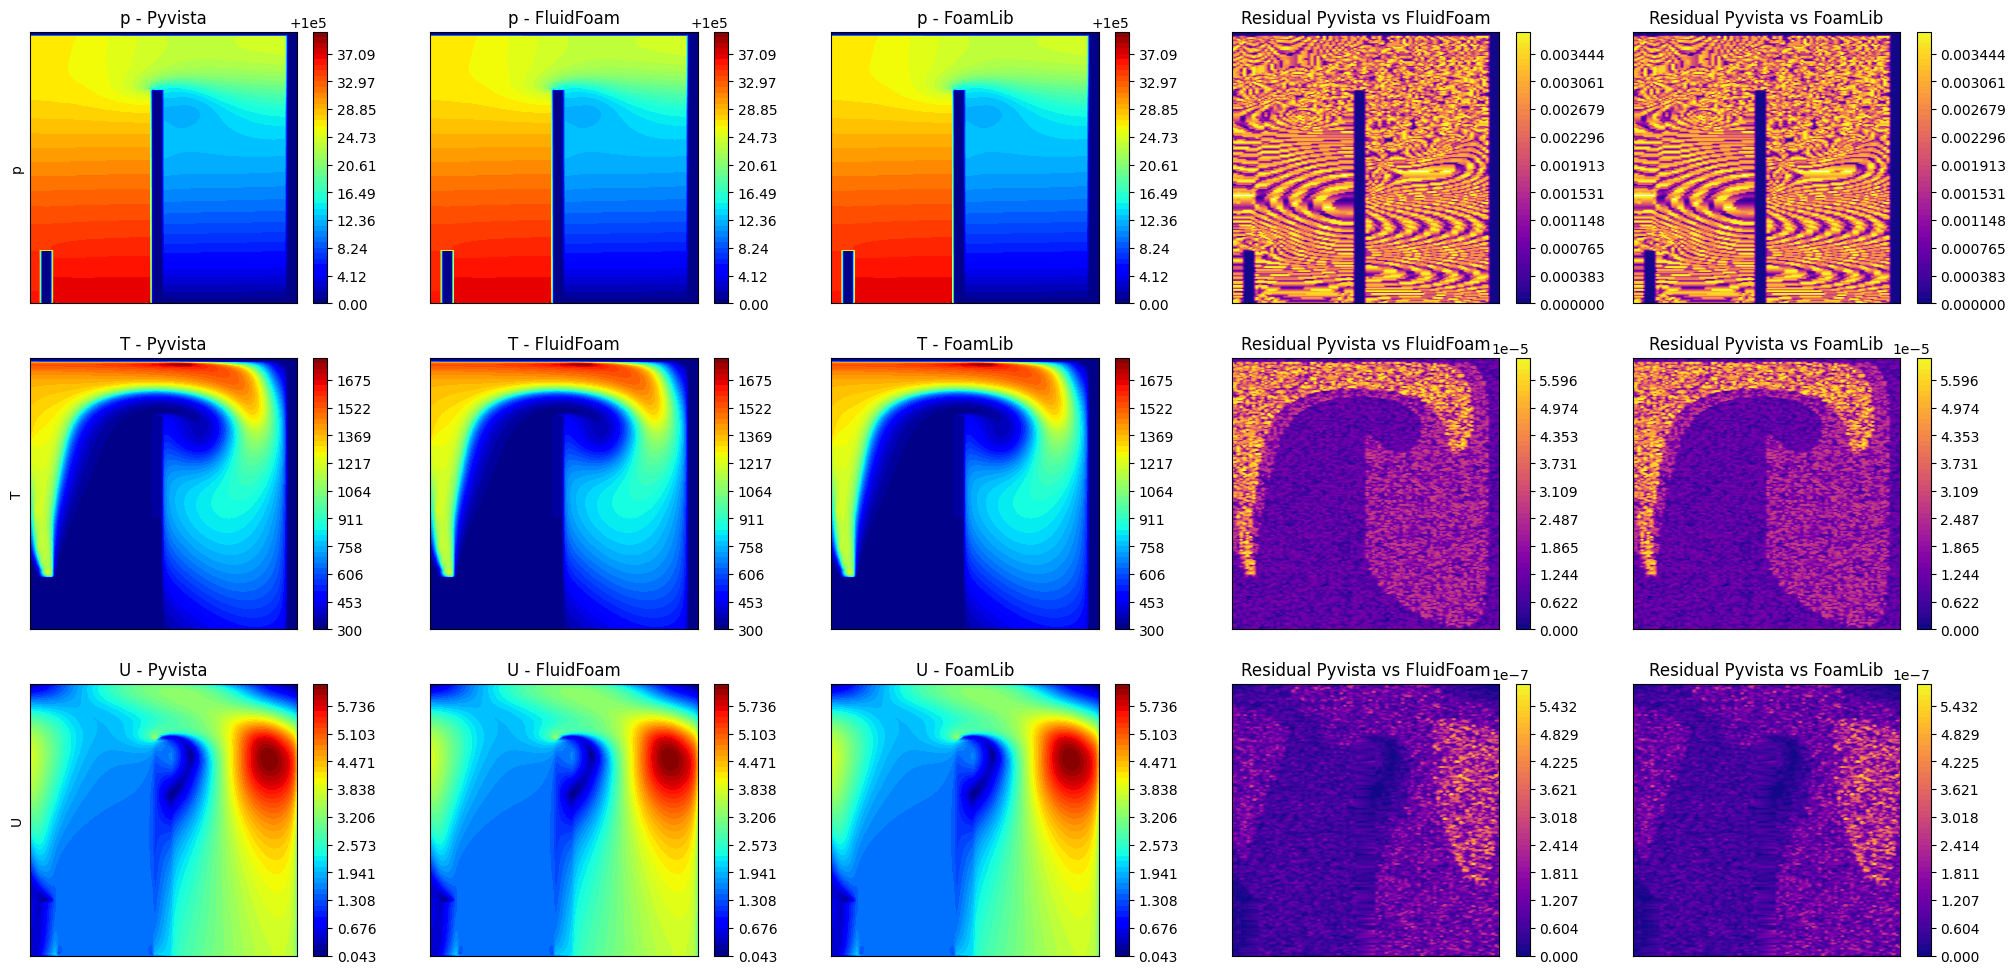

In [8]:
import numpy as np
nodes_full_mesh = of_decomposed.mesh().cell_centers().points
nodes_gas_mesh  = of_decomposed._region_mesh('gas').cell_centers().points

fig, axs = plt.subplots(len(fields), (len(snapshots_decomposed.keys())*2-1), figsize=(5 * (len(snapshots_decomposed.keys())*2-1), 4 * len(fields)))

for i, field in enumerate(fields):
    pv_res_decomposed = snapshots_decomposed['Pyvista'][field][0](-1)
    ff_res_decomposed = snapshots_decomposed['FluidFoam'][field][0](-1)
    fl_res_decomposed = snapshots_decomposed['FoamLib'][field][0](-1)

    if field == 'U':
        _ff = np.linalg.norm(ff_res_decomposed.reshape(-1, 3), axis=1)
        _pv = np.linalg.norm(pv_res_decomposed.reshape(-1, 3), axis=1)
        _fl = np.linalg.norm(fl_res_decomposed.reshape(-1, 3), axis=1)
        _mesh = nodes_gas_mesh
    else:
        _ff = ff_res_decomposed
        _pv = pv_res_decomposed
        _fl = fl_res_decomposed
        _mesh = nodes_full_mesh

    levels = np.linspace(min(_ff.min(), _pv.min(), _fl.min()), max(_ff.max(), _pv.max(), _fl.max()), 50)

    c = axs[i, 0].tricontourf(_mesh[:, 0], _mesh[:, 1], _pv, levels=levels, cmap='jet')
    axs[i, 1].tricontourf(_mesh[:, 0], _mesh[:, 1], _ff, levels=levels, cmap='jet')
    axs[i, 2].tricontourf(_mesh[:, 0], _mesh[:, 1], _fl, levels=levels, cmap='jet')

    _res_ff = np.abs(_ff - _pv)
    _res_fl = np.abs(_fl - _pv)
    res_levels = np.linspace(0, max(_res_ff.max(), _res_fl.max()), 50)
    
    c_res = axs[i, 3].tricontourf(_mesh[:, 0], _mesh[:, 1], _res_ff, levels=res_levels, cmap='plasma')
    axs[i, 4].tricontourf(_mesh[:, 0], _mesh[:, 1], _res_fl, levels=res_levels, cmap='plasma')

    fig.colorbar(c, ax=axs[i, 0])
    fig.colorbar(c, ax=axs[i, 1])
    fig.colorbar(c, ax=axs[i, 2])

    fig.colorbar(c_res, ax=axs[i, 3])
    fig.colorbar(c_res, ax=axs[i, 4])

    axs[i, 0].set_title(f'{field} - Pyvista')
    axs[i, 1].set_title(f'{field} - FluidFoam')
    axs[i, 2].set_title(f'{field} - FoamLib')

    axs[i, 3].set_title(f'Residual Pyvista vs FluidFoam')
    axs[i, 4].set_title(f'Residual Pyvista vs FoamLib')

    axs[i, 0].set_ylabel(f'{field}')

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

## Comparison of the computational times for both cases

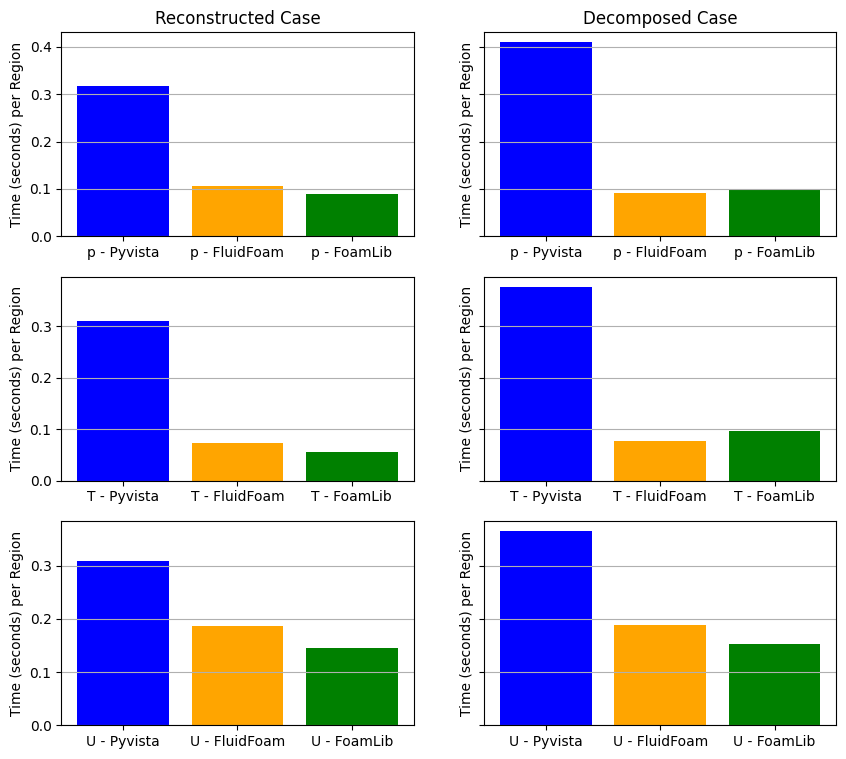

In [9]:
fig, axs = plt.subplots(len(fields), 2, figsize=(10, 3 * len(fields)), sharey='row')

for field_i, field in enumerate(fields):

    n_regions = len(of_decomposed._get_valid_regions_for_field(field))

    # Reconstructed case
    axs[field_i, 0].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_reconstructed['Pyvista'][field] / n_regions, comput_times_reconstructed['FluidFoam'][field] / n_regions, comput_times_reconstructed['FoamLib'][field] / n_regions], color=['blue', 'orange', 'green'])

    # Decomposed case
    axs[field_i, 1].bar([f'{field} - Pyvista', f'{field} - FluidFoam', f'{field} - FoamLib'], [comput_times_decomposed['Pyvista'][field] / n_regions, comput_times_decomposed['FluidFoam'][field] / n_regions, comput_times_decomposed['FoamLib'][field] / n_regions], color=['blue', 'orange', 'green'])

axs[0, 0].set_title('Reconstructed Case')
axs[0, 1].set_title('Decomposed Case')

for ax in axs.flatten():
    ax.set_ylabel('Time (seconds) per Region')
    ax.grid(True, axis='y')
